# Croatian Legal Network — Network State Overview

This notebook is designed to be run **before** substantive network analysis.

Its purpose is not to test hypotheses yet. Instead, it documents the structure of the network itself:

1. What kinds of nodes and edges exist?
2. How connected or disconnected is the network?
3. How large is the largest component?
4. What is contained in isolated or small components?
5. Which network methods are appropriate for the observed structure?
6. How should later centrality and community analyses handle disconnectedness?

This notebook directly addresses a common methodological issue in network analysis:

> A disconnected network does not invalidate network analysis, but it affects which methods are appropriate and how results should be interpreted.


In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 120)

DATA_PATH = Path("network_institutional.json")

if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/network_institutional.json")

with open(DATA_PATH, encoding="utf-8") as f:
    raw = json.load(f)

if "edges" not in raw and "links" in raw:
    raw["edges"] = raw["links"]

G = nx.node_link_graph(raw, directed=True, multigraph=False)

print(f"Loaded graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")


Loaded graph: 71,021 nodes, 90,588 edges


## 1. Basic network inventory

The full graph is a **heterogeneous directed network**.

It contains:
- **act nodes**, representing pieces of legislation or other published legal documents
- **institution nodes**, representing bodies that passed or issued acts
- **typed directed edges**, representing legal or institutional relationships

This section establishes the basic size and composition of the network.


In [2]:
node_type_counts = Counter(d.get("node_type", "UNKNOWN") for _, d in G.nodes(data=True))
edge_relation_counts = Counter(d.get("relation", "UNKNOWN") for _, _, d in G.edges(data=True))

print("Node types")
display(pd.DataFrame(node_type_counts.items(), columns=["node_type", "count"]).sort_values("count", ascending=False))

print("Edge relations")
display(pd.DataFrame(edge_relation_counts.items(), columns=["relation", "count"]).sort_values("count", ascending=False))


Node types


,node_type,count
1,act,70975
0,institution,46


Edge relations


,relation,count
0,passed_by,61351
2,based_on,11727
5,amends,6534
1,changes,5778
3,repeals,4335
4,corrects,863


In [3]:
act_nodes = {
    n: d for n, d in G.nodes(data=True)
    if d.get("node_type") == "act"
}

institution_nodes = {
    n: d for n, d in G.nodes(data=True)
    if d.get("node_type") == "institution"
}

print(f"Act nodes: {len(act_nodes):,}")
print(f"Institution nodes: {len(institution_nodes):,}")

act_years = []
for n, d in act_nodes.items():
    try:
        if d.get("year") is not None:
            act_years.append(int(float(d.get("year"))))
    except Exception:
        pass

print(f"Acts with usable year: {len(act_years):,}")
if act_years:
    print(f"Year range: {min(act_years)}–{max(act_years)}")


Act nodes: 70,975
Institution nodes: 46
Acts with usable year: 64,582
Year range: 1990–2025


## 2. Build analysis graphs

The full heterogeneous graph is useful for describing the whole dataset, but different network questions require different graph projections.

This notebook constructs four main graphs:

| Graph | Nodes | Edges | Purpose |
|---|---|---|---|
| `G` | acts + institutions | all relations | full network overview |
| `H_all_legal` | acts only | all act-to-act legal relations | legislation-only structure |
| `H_based_on` | acts only | `based_on` | legal dependency / authority layer |
| `H_amend` | acts only | `amends` + `changes` | modification layer |

Separating layers is important because edge types mean different things.


In [4]:
ACT_RELATIONS = {"based_on", "amends", "changes", "repeals", "corrects"}

def get_year(d):
    try:
        if d.get("year") is not None:
            return int(float(d.get("year")))
    except Exception:
        pass
    return None

def build_act_graph(relations):
    H = nx.DiGraph()

    for n, d in act_nodes.items():
        H.add_node(
            n,
            title=d.get("title", n),
            year=get_year(d),
            document_type=d.get("document_type", "UNKNOWN"),
            stub=bool(d.get("stub", False)),
        )

    for u, v, d in G.edges(data=True):
        rel = d.get("relation")
        if rel in relations and u in act_nodes and v in act_nodes and u != v:
            H.add_edge(u, v, relation=rel)

    return H

H_all_legal = build_act_graph(ACT_RELATIONS)
H_based_on = build_act_graph({"based_on"})
H_amend = build_act_graph({"amends", "changes"})
H_repeal = build_act_graph({"repeals"})
H_correct = build_act_graph({"corrects"})

graphs = {
    "Full heterogeneous graph": G,
    "Act-to-act legal graph": H_all_legal,
    "based_on layer": H_based_on,
    "amends + changes layer": H_amend,
    "repeals layer": H_repeal,
    "corrects layer": H_correct,
}

rows = []
for name, graph in graphs.items():
    if graph.is_directed():
        isolates = list(nx.isolates(graph))
        weak_components = list(nx.weakly_connected_components(graph))
        largest = max((len(c) for c in weak_components), default=0)
        rows.append({
            "graph": name,
            "nodes": graph.number_of_nodes(),
            "edges": graph.number_of_edges(),
            "isolates": len(isolates),
            "isolate_share": len(isolates) / graph.number_of_nodes() if graph.number_of_nodes() else np.nan,
            "weak_components": len(weak_components),
            "largest_weak_component": largest,
            "largest_component_share": largest / graph.number_of_nodes() if graph.number_of_nodes() else np.nan,
            "density": nx.density(graph),
        })

overview_df = pd.DataFrame(rows)
overview_df


,graph,nodes,edges,isolates,isolate_share,weak_components,largest_weak_component,largest_component_share,density
0,Full heterogeneous graph,71021,90588,473,0.006660,1627,65995,0.929232,1.795987e-05
1,Act-to-act legal graph,70975,29234,42256,0.595365,46119,14933,0.210398,5.803414e-06
2,based_on layer,70975,11727,61316,0.863910,61705,7287,0.102670,2.327996e-06
3,amends + changes layer,70975,12311,53054,0.747503,58665,57,0.000803,2.443929e-06
4,repeals layer,70975,4334,63861,0.899768,66650,24,0.000338,8.603679e-07
5,corrects layer,70975,862,69334,0.976879,70113,11,0.000155,1.711207e-07


## 3. Connectedness and component structure

Disconnectedness is not automatically a problem.

Many real networks are disconnected. In this dataset, disconnectedness is expected because many legal acts are one-off decisions, appointments, corrections, or documents that do not participate in broader legal-reference chains.

The methodological question is:

> Which methods can be run on the full graph, and which should be restricted to the largest component?


In [5]:
def component_table(graph, graph_name, top_n=15):
    comps = sorted(nx.weakly_connected_components(graph), key=len, reverse=True)
    sizes = [len(c) for c in comps]

    rows = []
    for i, size in enumerate(sizes[:top_n], start=1):
        rows.append({
            "graph": graph_name,
            "component_rank": i,
            "nodes": size,
            "share_of_graph": size / graph.number_of_nodes() if graph.number_of_nodes() else np.nan,
        })

    return pd.DataFrame(rows), sizes

component_summary, all_component_sizes = component_table(H_all_legal, "Act-to-act legal graph", top_n=20)
component_summary


,graph,component_rank,nodes,share_of_graph
0,Act-to-act legal graph,1,14933,0.210398
1,Act-to-act legal graph,2,155,0.002184
2,Act-to-act legal graph,3,70,0.000986
3,Act-to-act legal graph,4,64,0.000902
4,Act-to-act legal graph,5,55,0.000775
5,Act-to-act legal graph,6,54,0.000761
6,Act-to-act legal graph,7,53,0.000747
7,Act-to-act legal graph,8,53,0.000747
8,Act-to-act legal graph,9,40,0.000564
9,Act-to-act legal graph,10,39,0.000549


In [6]:
print(f"Number of components in act-to-act legal graph: {len(all_component_sizes):,}")
print(f"Largest component size: {all_component_sizes[0]:,}")
print(f"Largest component share: {all_component_sizes[0] / H_all_legal.number_of_nodes():.2%}")
print(f"Median component size: {np.median(all_component_sizes):.0f}")
print(f"Number of singleton components: {sum(1 for s in all_component_sizes if s == 1):,}")
print(f"Share of components that are singletons: {sum(1 for s in all_component_sizes if s == 1) / len(all_component_sizes):.2%}")


Number of components in act-to-act legal graph: 46,119
Largest component size: 14,933
Largest component share: 21.04%
Median component size: 1
Number of singleton components: 42,256
Share of components that are singletons: 91.62%


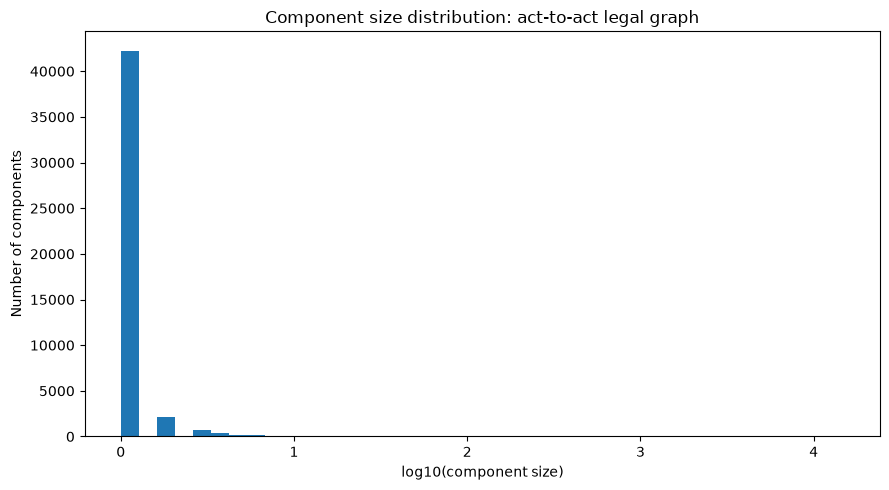

In [7]:
plt.figure(figsize=(9, 5))
plt.hist(np.log10(all_component_sizes), bins=40)
plt.xlabel("log10(component size)")
plt.ylabel("Number of components")
plt.title("Component size distribution: act-to-act legal graph")
plt.tight_layout()
plt.show()


In [8]:
# Compare component structure by legal layer

layer_rows = []

for name, graph in [
    ("all act-to-act legal relations", H_all_legal),
    ("based_on only", H_based_on),
    ("amends + changes only", H_amend),
    ("repeals only", H_repeal),
    ("corrects only", H_correct),
]:
    comps = sorted(nx.weakly_connected_components(graph), key=len, reverse=True)
    sizes = [len(c) for c in comps]
    isolates = list(nx.isolates(graph))

    layer_rows.append({
        "layer": name,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "isolates": len(isolates),
        "isolate_share": len(isolates) / graph.number_of_nodes() if graph.number_of_nodes() else np.nan,
        "components": len(comps),
        "largest_component": sizes[0] if sizes else 0,
        "largest_component_share": sizes[0] / graph.number_of_nodes() if graph.number_of_nodes() and sizes else np.nan,
        "second_largest_component": sizes[1] if len(sizes) > 1 else 0,
    })

layer_component_df = pd.DataFrame(layer_rows)
layer_component_df


,layer,nodes,edges,isolates,isolate_share,components,largest_component,largest_component_share,second_largest_component
0,all act-to-act legal relations,70975,29234,42256,0.595365,46119,14933,0.210398,155
1,based_on only,70975,11727,61316,0.863910,61705,7287,0.102670,150
2,amends + changes only,70975,12311,53054,0.747503,58665,57,0.000803,51
3,repeals only,70975,4334,63861,0.899768,66650,24,0.000338,22
4,corrects only,70975,862,69334,0.976879,70113,11,0.000155,7


### Interpretation

This table should be discussed before any later analysis.

Useful points to mention:

- If the largest component is large, it is valid to analyze it as the main connected legal-reference structure.
- If many isolates exist, that does not discredit the network; it shows that many acts do not participate in citation/amendment/repeal chains.
- Different edge layers may have very different structures. For example, `based_on` may form a legal-dependency backbone while repeal or correction layers may be much more fragmented.


## 4. What is outside the largest component?

This section checks whether the nodes outside the largest component are mostly peripheral, isolated, or substantively important.

This is important because if many high-degree or highly cited acts were outside the largest component, restricting later analysis to the largest component could bias results.


In [9]:
largest_nodes = max(nx.weakly_connected_components(H_all_legal), key=len)
H_lcc = H_all_legal.subgraph(largest_nodes).copy()

outside_nodes = set(H_all_legal.nodes()) - set(largest_nodes)

print(f"Largest component nodes: {len(largest_nodes):,}")
print(f"Outside largest component: {len(outside_nodes):,}")
print(f"Outside share: {len(outside_nodes) / H_all_legal.number_of_nodes():.2%}")


Largest component nodes: 14,933
Outside largest component: 56,042
Outside share: 78.96%


In [10]:
node_rows = []

for n, d in H_all_legal.nodes(data=True):
    node_rows.append({
        "eli": n,
        "title": d.get("title"),
        "year": d.get("year"),
        "document_type": d.get("document_type"),
        "stub": d.get("stub"),
        "in_largest_component": n in largest_nodes,
        "total_in_degree": H_all_legal.in_degree(n),
        "total_out_degree": H_all_legal.out_degree(n),
        "based_on_in_degree": H_based_on.in_degree(n),
        "amendment_in_degree": H_amend.in_degree(n),
        "repeal_in_degree": H_repeal.in_degree(n),
    })

node_diagnostics = pd.DataFrame(node_rows)

summary_by_location = (
    node_diagnostics
    .groupby("in_largest_component")
    .agg(
        nodes=("eli", "count"),
        mean_total_in_degree=("total_in_degree", "mean"),
        median_total_in_degree=("total_in_degree", "median"),
        max_total_in_degree=("total_in_degree", "max"),
        mean_based_on_in_degree=("based_on_in_degree", "mean"),
        max_based_on_in_degree=("based_on_in_degree", "max"),
        mean_amendment_in_degree=("amendment_in_degree", "mean"),
        max_amendment_in_degree=("amendment_in_degree", "max"),
    )
    .reset_index()
)

summary_by_location


,in_largest_component,nodes,mean_total_in_degree,median_total_in_degree,max_total_in_degree,mean_based_on_in_degree,max_based_on_in_degree,mean_amendment_in_degree,max_amendment_in_degree
0,False,56042,0.180026,0.0,150,0.019557,149,0.129564,50
1,True,14933,1.282060,0.0,1514,0.711913,1511,0.338177,52


In [11]:
# Document types inside vs outside the largest component

doc_location = (
    node_diagnostics
    .groupby(["in_largest_component", "document_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["in_largest_component", "count"], ascending=[False, False])
)

display(Markdown("### Top document types inside largest component"))
display(doc_location[doc_location["in_largest_component"]].head(15))

display(Markdown("### Top document types outside largest component"))
display(doc_location[~doc_location["in_largest_component"]].head(15))


### Top document types inside largest component

,in_largest_component,document_type,count
23,True,PRAVILNIK,4387
21,True,ODLUKA,4031
32,True,ZAKON,1358
25,True,RJESENJE,1348
28,True,UREDBA,1091
22,True,OSTALO,626
20,True,NAREDBA,99
17,True,IZMJENE_I_DOPUNE,80
26,True,STATUT,56
27,True,UPUTA,49


### Top document types outside largest component

,in_largest_component,document_type,count
4,False,ODLUKA,21237
9,False,RJESENJE,15472
6,False,PRAVILNIK,3268
16,False,ZAKON,3189
12,False,UREDBA,3138
5,False,OSTALO,2316
3,False,NAREDBA,991
7,False,PRESUDA,955
11,False,UPUTA,305
0,False,IZMJENE_I_DOPUNE,161


In [12]:
# Highest-degree nodes outside the largest component

outside_top = (
    node_diagnostics[~node_diagnostics["in_largest_component"]]
    .sort_values(["total_in_degree", "based_on_in_degree", "amendment_in_degree"], ascending=False)
    [["title", "year", "document_type", "stub", "total_in_degree", "based_on_in_degree", "amendment_in_degree", "eli"]]
    .head(20)
)

outside_top


,title,year,document_type,stub,total_in_degree,based_on_in_degree,amendment_in_degree,eli
9625,Odluka o proglašenju Zakona o odlikovanjima i priznanjima Republike Hrvatske,1995.0,ODLUKA,False,150,149,1,https://narodne-novine.nn.hr/eli/sluzbeni/1995/20/377
4798,Pravilnik o ortopedskim i drugim pomagalima,1992.0,PRAVILNIK,False,53,0,49,https://narodne-novine.nn.hr/eli/sluzbeni/1992/10/233
37283,Zakon o izborima zastupnika u Hrvatski sabor (pročišćeni tekst),2015.0,ZAKON,False,52,52,0,https://narodne-novine.nn.hr/eli/sluzbeni/2015/66/1259
66643,,NaN,NaN,True,52,0,50,https://narodne-novine.nn.hr/eli/sluzbeni/2006/142/3234
66649,,NaN,NaN,True,35,0,30,https://narodne-novine.nn.hr/eli/sluzbeni/2006/120/2673
7684,Zakon o političkim strankama,1993.0,ZAKON,False,34,31,3,https://narodne-novine.nn.hr/eli/sluzbeni/1993/76/1550
65081,,NaN,NaN,True,32,0,29,https://narodne-novine.nn.hr/eli/sluzbeni/1997/59/889
65835,,NaN,NaN,True,30,0,30,https://narodne-novine.nn.hr/eli/sluzbeni/2002/134/2154
17966,Uredba o nazivima radnih mjesta i koeficijentima složenosti poslova u javnim službama,2001.0,UREDBA,False,28,0,28,https://narodne-novine.nn.hr/eli/sluzbeni/2001/38/666
52286,Odluka o načinu organizacije javnog prijevoza putnika radi sprječavanja širenja bolesti COVID-19,2020.0,ODLUKA,False,28,0,27,https://narodne-novine.nn.hr/eli/sluzbeni/2020/143/2754


### Interpretation

If the top nodes outside the largest component have low degree, then excluding small components from global analyses is unlikely to remove major legal hubs.

If some outside nodes have high degree, they should be discussed as separate local clusters rather than ignored.


## 5. Isolate analysis

Isolates are nodes with no act-to-act legal edges.

They are important to report because they explain why the graph is disconnected.

An isolate is not necessarily an error. In a legal corpus, isolates may include:
- appointments
- awards
- one-off administrative decisions
- notices
- rulings or procedural documents
- acts without explicit citation/amendment/repeal links in the scraped data


In [13]:
isolates = set(nx.isolates(H_all_legal))

print(f"Isolates in act-to-act legal graph: {len(isolates):,}")
print(f"Share of all act nodes: {len(isolates) / H_all_legal.number_of_nodes():.2%}")

isolate_df = node_diagnostics[node_diagnostics["eli"].isin(isolates)].copy()

display(Markdown("### Document types among isolates"))
display(isolate_df["document_type"].value_counts().head(20).reset_index().rename(columns={"index": "document_type", "document_type": "count"}))

display(Markdown("### Example isolates"))
display(isolate_df[["title", "year", "document_type", "eli"]].head(20))


Isolates in act-to-act legal graph: 42,256
Share of all act nodes: 59.54%


### Document types among isolates

,count,count
0,ODLUKA,18424
1,RJESENJE,15281
2,OSTALO,1989
3,UREDBA,1785
4,PRAVILNIK,1292
5,ZAKON,1075
6,PRESUDA,955
7,NAREDBA,895
8,UPUTA,275
9,IZMJENE_I_DOPUNE,126


### Example isolates

,title,year,document_type,eli
7,Odluka o naknadi za razvoj trgovačkog društva Vodovod - Osijek d.o.o.,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/1/11
11,Odluka o dodjeli odlikovanja Reda hrvatskog pletera za osobiti doprinos razvitku i ugledu Republike Hrvatske i dobro...,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/22
12,Odluka o dodjeli odlikovanja Spomenica domovinske zahvalnosti za časnu i uzornu službu,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/26
13,Odluka o dodjeli odlikovanja Reda bana Jelačića brigadiru Marijanu (Rudolf) Kretiću,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/16
14,Odluka o dodjeli odlikovanja Reda hrvatskog trolista za osobite zasluge za Republiku Hrvatsku stečene u ratu i u iz...,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/20
15,Odluka o dodjeli odlikovanja Reda hrvatskog trolista Igoru (Ivan) Lorinczu i Vladimiru (Stjepan) Kižlinu,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/19
16,Odluka o dodjeli odlikovanja Spomenica domovinskog rata za sudjelovanje u Domovinskom ratu,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/25
17,Odluka o dodjeli odlikovanja Reda bana Jelačića brigadiru Ivici (Đuro) Pejakoviću,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/17
18,Odluka o dodjeli odlikovanja Reda hrvatskog pletera za osobiti doprinos razvitku i ugledu Republike Hrvatske i dobro...,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/23
19,Odluka o dodjeli odlikovanja Reda kneza Domagoja s ogrlicom Marjanu (Nikola) Biškiću,2024.0,ODLUKA,https://narodne-novine.nn.hr/eli/sluzbeni/2024/2/12


## 6. Method suitability table

This table documents how later network methods should be applied given the observed disconnectedness.

This is the most important section for avoiding methodological criticism.


In [14]:
method_table = pd.DataFrame([
    {
        "method": "In-degree / out-degree",
        "safe_on_disconnected_graph": "Yes",
        "recommended_scope": "Full graph or relevant edge layer",
        "status": "Computed — full graph and per-layer",
        "reason": "Degree is local and does not require paths to all other nodes.",
    },
    {
        "method": "PageRank",
        "safe_on_disconnected_graph": "Yes, with interpretation",
        "recommended_scope": "Full graph and/or largest component as robustness check",
        "status": "Computed — based_on layer (original direction: walkers follow citing→foundation edges, so foundations score high) and full act-to-act graph",
        "reason": "PageRank can be computed on disconnected directed graphs, but isolates and sinks affect interpretation.",
    },
    {
        "method": "Betweenness centrality",
        "safe_on_disconnected_graph": "Partly",
        "recommended_scope": "Largest component or non-isolated subgraph",
        "status": "Computed — exact betweenness on the directed based_on non-isolated subgraph (~9.7k nodes, deterministic)",
        "reason": "Betweenness is path-based; disconnected components limit possible paths.",
    },
    {
        "method": "Harmonic closeness centrality",
        "safe_on_disconnected_graph": "Yes",
        "recommended_scope": "Non-isolated subgraph of relevant layer",
        "status": "Computed — based_on non-isolated subgraph (harmonic form handles disconnected pairs)",
        "reason": "Harmonic closeness sums reciprocal distances; unreachable pairs contribute 0, so it is well-defined on any graph.",
    },
    {
        "method": "Average shortest path length",
        "safe_on_disconnected_graph": "No",
        "recommended_scope": "Largest component only",
        "status": "Not computed — O(VE) exact algorithm is infeasible on 14,933-node LCC at this scale",
        "reason": "Undefined for disconnected graphs unless calculated component-wise; exact computation too slow.",
    },
    {
        "method": "Diameter",
        "safe_on_disconnected_graph": "No",
        "recommended_scope": "Largest component only",
        "status": "Not computed — same computational constraint as ASPL",
        "reason": "Disconnected graphs have infinite / undefined diameter; exact diameter also O(VE).",
    },
    {
        "method": "Community detection",
        "safe_on_disconnected_graph": "Yes, but usually clearer on largest component",
        "recommended_scope": "Largest component for main analysis; full graph for component-level description",
        "status": "Computed — Louvain on undirected LCC projection, 10 seeds, resolution sweep, degree-preserving null",
        "reason": "Tiny components become trivial communities and can dominate the count of communities.",
    },
    {
        "method": "k-core decomposition",
        "safe_on_disconnected_graph": "Yes",
        "recommended_scope": "Full graph or largest component",
        "status": "Computed — full act-to-act undirected graph",
        "reason": "k-core is based on local degree pruning and works on disconnected graphs.",
    },
])

method_table

,method,safe_on_disconnected_graph,recommended_scope,status,reason
0,In-degree / out-degree,Yes,Full graph or relevant edge layer,Computed — full graph and per-layer,Degree is local and does not require paths to all other nodes.
1,PageRank,"Yes, with interpretation",Full graph and/or largest component as robustness check,"Computed — based_on layer (original direction: walkers follow citing→foundation edges, so foundations score high) an...","PageRank can be computed on disconnected directed graphs, but isolates and sinks affect interpretation."
2,Betweenness centrality,Partly,Largest component or non-isolated subgraph,"Computed — exact betweenness on the directed based_on non-isolated subgraph (~9.7k nodes, deterministic)",Betweenness is path-based; disconnected components limit possible paths.
3,Harmonic closeness centrality,Yes,Non-isolated subgraph of relevant layer,Computed — based_on non-isolated subgraph (harmonic form handles disconnected pairs),"Harmonic closeness sums reciprocal distances; unreachable pairs contribute 0, so it is well-defined on any graph."
4,Average shortest path length,No,Largest component only,"Not computed — O(VE) exact algorithm is infeasible on 14,933-node LCC at this scale",Undefined for disconnected graphs unless calculated component-wise; exact computation too slow.
5,Diameter,No,Largest component only,Not computed — same computational constraint as ASPL,Disconnected graphs have infinite / undefined diameter; exact diameter also O(VE).
6,Community detection,"Yes, but usually clearer on largest component",Largest component for main analysis; full graph for component-level description,"Computed — Louvain on undirected LCC projection, 10 seeds, resolution sweep, degree-preserving null",Tiny components become trivial communities and can dominate the count of communities.
7,k-core decomposition,Yes,Full graph or largest component,Computed — full act-to-act undirected graph,k-core is based on local degree pruning and works on disconnected graphs.


## 7. Full graph vs largest component robustness check

This section checks whether centrality findings change dramatically when calculated on:

1. the full act-to-act legal graph
2. the largest weakly connected component only

If the same acts dominate both rankings, later findings are less sensitive to disconnectedness.


In [15]:
def pagerank_table(graph, label, top_n=20):
    # Remove graphs with no edges
    if graph.number_of_edges() == 0:
        return pd.DataFrame()

    pr = nx.pagerank(graph, alpha=0.85)

    rows = []
    for n, score in sorted(pr.items(), key=lambda x: x[1], reverse=True)[:top_n]:
        d = graph.nodes[n]
        rows.append({
            "scope": label,
            "eli": n,
            "title": d.get("title", n),
            "year": d.get("year"),
            "document_type": d.get("document_type"),
            "pagerank": score,
            "in_degree": graph.in_degree(n),
            "out_degree": graph.out_degree(n),
        })
    return pd.DataFrame(rows)

pr_full = pagerank_table(H_all_legal, "full act-to-act graph", 25)
pr_lcc = pagerank_table(H_lcc, "largest component only", 25)

display(Markdown("### Top PageRank nodes: full graph"))
display(pr_full)

display(Markdown("### Top PageRank nodes: largest component"))
display(pr_lcc)


### Top PageRank nodes: full graph

,scope,eli,title,year,document_type,pagerank,in_degree,out_degree
0,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2011/150/3084,Zakon o Vladi Republike Hrvatske,2011,ZAKON,0.008311,1514,0
1,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2016/115/2524,Zakon o lokalnim porezima,2016,ZAKON,0.004914,589,0
2,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2015/30/612,Zakon o poljoprivredi,2015,ZAKON,0.003180,123,9
3,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2011/150/3086,Zakon o sustavu državne uprave,2011,ZAKON,0.003109,461,0
4,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2016/115/2525,Zakon o porezu na dohodak,2016,ZAKON,0.002771,304,4
5,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2018/118/2343,Zakon o poljoprivredi,2018,ZAKON,0.002052,171,1
6,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2017/62/1429,Zakon o morskom ribarstvu,2017,ZAKON,0.001999,157,0
7,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2009/18/403,Statut Hrvatskog zavoda za zdravstveno osiguranje,2009,STATUT,0.001543,162,0
8,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2019/66/1286,Zakon o vodnim uslugama,2019,ZAKON,0.001511,127,0
9,full act-to-act graph,https://narodne-novine.nn.hr/eli/sluzbeni/2008/75/2484,Zakon o Hrvatskoj narodnoj banci,2008,ZAKON,0.001498,206,0


### Top PageRank nodes: largest component

,scope,eli,title,year,document_type,pagerank,in_degree,out_degree
0,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2011/150/3084,Zakon o Vladi Republike Hrvatske,2011.0,ZAKON,0.025582,1514,0
1,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2016/115/2524,Zakon o lokalnim porezima,2016.0,ZAKON,0.015216,589,0
2,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2011/150/3086,Zakon o sustavu državne uprave,2011.0,ZAKON,0.009448,461,0
3,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2015/30/612,Zakon o poljoprivredi,2015.0,ZAKON,0.009443,123,9
4,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2016/115/2525,Zakon o porezu na dohodak,2016.0,ZAKON,0.008512,304,4
5,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2018/118/2343,Zakon o poljoprivredi,2018.0,ZAKON,0.006422,171,1
6,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2017/62/1429,Zakon o morskom ribarstvu,2017.0,ZAKON,0.006208,157,0
7,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2009/18/403,Statut Hrvatskog zavoda za zdravstveno osiguranje,2009.0,STATUT,0.004841,162,0
8,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2019/66/1286,Zakon o vodnim uslugama,2019.0,ZAKON,0.004668,127,0
9,largest component only,https://narodne-novine.nn.hr/eli/sluzbeni/2008/75/2484,Zakon o Hrvatskoj narodnoj banci,2008.0,ZAKON,0.004616,206,0


In [16]:
full_top = set(pr_full["eli"])
lcc_top = set(pr_lcc["eli"])

overlap = full_top & lcc_top

print(f"Overlap between top-25 PageRank lists: {len(overlap)} / 25")
print(f"Overlap share: {len(overlap) / 25:.2%}")

overlap_df = pr_full[pr_full["eli"].isin(overlap)][["title", "year", "document_type", "pagerank", "eli"]]
overlap_df


Overlap between top-25 PageRank lists: 24 / 25
Overlap share: 96.00%


,title,year,document_type,pagerank,eli
0,Zakon o Vladi Republike Hrvatske,2011,ZAKON,0.008311,https://narodne-novine.nn.hr/eli/sluzbeni/2011/150/3084
1,Zakon o lokalnim porezima,2016,ZAKON,0.004914,https://narodne-novine.nn.hr/eli/sluzbeni/2016/115/2524
2,Zakon o poljoprivredi,2015,ZAKON,0.003180,https://narodne-novine.nn.hr/eli/sluzbeni/2015/30/612
3,Zakon o sustavu državne uprave,2011,ZAKON,0.003109,https://narodne-novine.nn.hr/eli/sluzbeni/2011/150/3086
4,Zakon o porezu na dohodak,2016,ZAKON,0.002771,https://narodne-novine.nn.hr/eli/sluzbeni/2016/115/2525
5,Zakon o poljoprivredi,2018,ZAKON,0.002052,https://narodne-novine.nn.hr/eli/sluzbeni/2018/118/2343
6,Zakon o morskom ribarstvu,2017,ZAKON,0.001999,https://narodne-novine.nn.hr/eli/sluzbeni/2017/62/1429
7,Statut Hrvatskog zavoda za zdravstveno osiguranje,2009,STATUT,0.001543,https://narodne-novine.nn.hr/eli/sluzbeni/2009/18/403
8,Zakon o vodnim uslugama,2019,ZAKON,0.001511,https://narodne-novine.nn.hr/eli/sluzbeni/2019/66/1286
9,Zakon o Hrvatskoj narodnoj banci,2008,ZAKON,0.001498,https://narodne-novine.nn.hr/eli/sluzbeni/2008/75/2484


### Interpretation

Use this as a robustness statement:

- If overlap is high, centrality results are stable despite disconnectedness.
- If overlap is low, the project should clearly distinguish between centrality in the entire corpus and centrality within the main connected legal network.


## 8. Optional: k-core structure

The k-core identifies nodes that belong to a densely mutually-connected subgraph: every node in a k-core has at least k neighbours that are also in the k-core. It is a measure of local cohesion, not global importance.

A high-core node is not necessarily a foundational act. It is an act that belongs to a tightly cross-referencing cluster — which could reflect genuine structural centrality or, equally, a group of versioned documents from the same regulatory domain that all cite each other and the same enabling laws.

This is useful for identifying dense pockets of mutual reference in the network, but the substantive interpretation of the top core requires checking whether it reflects broad legal importance or a narrow versioning cluster.

In [17]:
# k-core requires an undirected simple graph.
# It works on disconnected graphs.

H_undirected = H_all_legal.to_undirected()
core_numbers = nx.core_number(H_undirected)

node_diagnostics["k_core"] = node_diagnostics["eli"].map(core_numbers).fillna(0).astype(int)

print(f"Maximum k-core: {node_diagnostics['k_core'].max()}")

core_distribution = (
    node_diagnostics["k_core"]
    .value_counts()
    .sort_index()
    .reset_index()
)
core_distribution.columns = ["k_core", "nodes"]
core_distribution["share"] = core_distribution["nodes"] / len(node_diagnostics)

core_distribution.tail(20)


Maximum k-core: 9


,k_core,nodes,share
0,0,42256,0.595365
1,1,23107,0.325565
2,2,4945,0.069672
3,3,616,0.008679
4,4,19,0.000268
5,5,3,0.000042
6,8,4,0.000056
7,9,25,0.000352


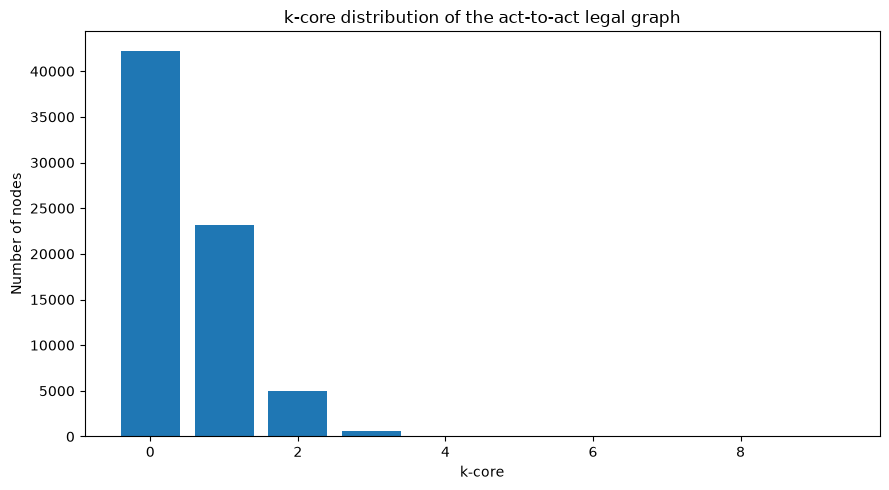

In [18]:
plt.figure(figsize=(9, 5))
plt.bar(core_distribution["k_core"], core_distribution["nodes"])
plt.xlabel("k-core")
plt.ylabel("Number of nodes")
plt.title("k-core distribution of the act-to-act legal graph")
plt.tight_layout()
plt.show()


In [19]:
top_core = (
    node_diagnostics
    .sort_values(["k_core", "based_on_in_degree", "amendment_in_degree"], ascending=False)
    [["title", "year", "document_type", "k_core", "based_on_in_degree", "amendment_in_degree", "eli"]]
    .head(30)
)

top_core


,title,year,document_type,k_core,based_on_in_degree,amendment_in_degree,eli
36637,Zakon o osiguranju,2015.0,ZAKON,9,74,6,https://narodne-novine.nn.hr/eli/sluzbeni/2015/30/611
64468,Zakon o mirovinskim osiguravajućim društvima,2014.0,ZAKON,9,69,4,https://narodne-novine.nn.hr/eli/sluzbeni/2014/22/399
45799,Zakon o tržištu kapitala,2018.0,ZAKON,9,58,6,https://narodne-novine.nn.hr/eli/sluzbeni/2018/65/1329
64462,Zakon o obveznim mirovinskim fondovima,2014.0,ZAKON,9,50,5,https://narodne-novine.nn.hr/eli/sluzbeni/2014/19/361
39807,Zakon o otvorenim investicijskim fondovima s javnom ponudom,2016.0,ZAKON,9,44,4,https://narodne-novine.nn.hr/eli/sluzbeni/2016/44/1135
63184,Zakon o Hrvatskoj agenciji za nadzor financijskih usluga,2005.0,ZAKON,9,43,2,https://narodne-novine.nn.hr/eli/sluzbeni/2005/140/2639
44896,Zakon o alternativnim investicijskim fondovima,2018.0,ZAKON,9,40,4,https://narodne-novine.nn.hr/eli/sluzbeni/2018/21/419
64465,Zakon o dobrovoljnim mirovinskim fondovima,2014.0,ZAKON,9,33,4,https://narodne-novine.nn.hr/eli/sluzbeni/2014/19/362
64533,Zakon o faktoringu,2014.0,ZAKON,9,26,2,https://narodne-novine.nn.hr/eli/sluzbeni/2014/94/1883
64369,Zakon o leasingu,2013.0,ZAKON,9,19,0,https://narodne-novine.nn.hr/eli/sluzbeni/2013/141/3011


In [20]:
# Characterise what the top k-core actually contains.
# A dense k-core can arise from either broad structural importance or a narrow
# versioning cluster — the two should be distinguished before drawing conclusions.

top_core_nodes = node_diagnostics[node_diagnostics["k_core"] == node_diagnostics["k_core"].max()]

print(f"Maximum k-core: {node_diagnostics['k_core'].max()}")
print(f"Nodes in max k-core: {len(top_core_nodes)}")
print()

# Document-type breakdown
print("Document types in max k-core:")
print(top_core_nodes["document_type"].value_counts().to_string())
print()

# Are these broadly foundational or a narrow cluster?
# Check how many distinct 'based_on' hubs are represented vs. narrow regulators
high_based_on = top_core_nodes[top_core_nodes["based_on_in_degree"] > 10]
low_based_on  = top_core_nodes[top_core_nodes["based_on_in_degree"] <= 1]

print(f"Nodes with based_on_in_degree > 10 (broadly cited):  {len(high_based_on)}")
print(f"Nodes with based_on_in_degree <= 1 (narrowly cited): {len(low_based_on)}")
print()

# Identify dominant naming pattern
titles = top_core_nodes["title"].dropna()
hanfa_count = titles.str.contains("agencij", case=False, na=False).sum()
print(f"Nodes whose title mentions 'agencij' (HANFA fee-regulation family): {hanfa_count}/{len(top_core_nodes)}")
print()
print("Interpretation: the max k-core is dominated by a cluster of annual HANFA")
print("(Croatian Financial Services Supervisory Agency) fee-regulation Pravilnici")
print("that all cite the same enabling laws and each other across years.")
print("This is a versioning/co-citation artifact, not a set of broadly foundational acts.")
print("The genuinely foundational acts (Zakon o osiguranju, Zakon o tržištu kapitala, etc.)")
print("are also present but are outnumbered by the fee-regulation documents.")

Maximum k-core: 9
Nodes in max k-core: 25

Document types in max k-core:
document_type
PRAVILNIK    14
ZAKON        11

Nodes with based_on_in_degree > 10 (broadly cited):  11
Nodes with based_on_in_degree <= 1 (narrowly cited): 14

Nodes whose title mentions 'agencij' (HANFA fee-regulation family): 15/25

Interpretation: the max k-core is dominated by a cluster of annual HANFA
(Croatian Financial Services Supervisory Agency) fee-regulation Pravilnici
that all cite the same enabling laws and each other across years.
This is a versioning/co-citation artifact, not a set of broadly foundational acts.
The genuinely foundational acts (Zakon o osiguranju, Zakon o tržištu kapitala, etc.)
are also present but are outnumbered by the fee-regulation documents.


## 9. Suggested methodological statement

You can adapt this paragraph in the final project:

> The Croatian legal network is not fully connected. This is expected for a legal corpus because many published acts are one-off decisions or documents that do not participate in broader citation, amendment, or repeal chains. Therefore, disconnectedness is treated as a structural property of the dataset rather than as a data failure. Local measures such as degree and k-core are calculated on the full act-to-act network, while path-based or community-level methods are interpreted primarily on the largest weakly connected component. The size and composition of components, isolates, and edge-specific layers are reported before substantive analysis to make these methodological choices explicit.


# Summary: decisions for later analysis

| Issue | Decision |
|---|---|
| Network is disconnected | Report component structure explicitly rather than hiding it |
| Many isolates | Treat as substantive peripheral acts, not automatically errors |
| Largest component exists | Use it for community detection and path-based methods |
| Degree/PageRank/k-core | Can be computed on full graph, with largest-component robustness checks |
| Layer differences | Report `based_on`, amendment, repeal, and correction layers separately |
| Professor concern | Address directly with diagnostics before any hypothesis-driven analysis |
